In [33]:
#import pandas as pd
#import numpy as np

In [34]:
# Load training and test datasets
#train_df = pd.read_csv("train_data.csv")
#test_df = pd.read_csv("test_data.csv")

In [35]:
train_df.head()

,Tweet,Sentiment_Label
0,the new york times trudeau condemns freedom co...,1
1,new column dropping tomorrow with analysis on ...,2
2,who knew that high school students and truck d...,1
3,glad to be,2
4,fucking journalists canât stand people standin...,2


In [36]:
test_df.head()


,Tweet,Sentiment_Label
0,ontario premier tyrant doug ford imposes âstat...,0
1,this is so good,2
2,con mps some freedom convoy protesters cant ge...,2
3,this need to heard talked about and spread wid...,0
4,ships participating in the flotilla to break t...,1


In [40]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Assuming train_df and test_df have columns 'Tweet' and 'Sentiment_Label'
X_train_texts = train_df['Tweet'].astype(str)
X_test_texts = test_df['Tweet'].astype(str)
y_train = train_df['Sentiment_Label']
y_test = test_df['Sentiment_Label']

# Tokenizer setup
tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_texts)

# Convert texts to sequences of integers
X_train_seq = tokenizer.texts_to_sequences(X_train_texts)
X_test_seq = tokenizer.texts_to_sequences(X_test_texts)

# Determine max length for padding
max_len = max(len(seq) for seq in X_train_seq)  # or fix max_len like 100 if you prefer

# Pad sequences so all have the same length
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')


In [41]:
#To handle class imbalance without oversampling:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))


In [42]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Bidirectional, GRU, Dropout, Dense

inputs = Input(shape=(max_len,))
x = Embedding(input_dim=10000, output_dim=128)(inputs)
x = Bidirectional(GRU(64, return_sequences=True))(x)
x = Dropout(0.5)(x)
x = Bidirectional(GRU(32))(x)
x = Dropout(0.5)(x)
x = Dense(32, activation='relu')(x)
x = Dropout(0.3)(x)
outputs = Dense(3, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_1 (Embedding)              │ (None, 80, 128)             │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_2 (Bidirectional)      │ (None, 80, 128)             │          74,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 80, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_3 (Bidirectional)      │ (None, 64)                  │          31,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,387,779 (5.29 MB)

 Trainable params: 1,387,779 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [43]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)


In [44]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Define EarlyStopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Define ModelCheckpoint — use '.keras' extension for full model saving
checkpoint = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_loss',
    save_best_only=True
)

# Compile your model (if not compiled already)
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Now train the model with callbacks
history = model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 95s 115ms/step - accuracy: 0.4831 - loss: 1.0014 - val_accuracy: 0.6987 - val_loss: 0.6793
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 88s 117ms/step - accuracy: 0.7469 - loss: 0.6251 - val_accuracy: 0.7430 - val_loss: 0.6101
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 102s 136ms/step - accuracy: 0.8135 - loss: 0.4728 - val_accuracy: 0.7608 - val_loss: 0.5858
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 76s 101ms/step - accuracy: 0.8590 - loss: 0.3668 - val_accuracy: 0.7482 - val_loss: 0.6420
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.8977 - loss: 0.2872 - val_accuracy: 0.7477 - val_loss: 0.6678
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 44s 58ms/step - accuracy: 0.9227 - loss: 0.2214 - val_accuracy: 0.7363 - val_loss: 0.8185


In [45]:
from tensorflow.keras.models import load_model

# Load the best model saved during training
best_model = load_model('best_model.keras')

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(X_test_pad, y_test)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7613 - loss: 0.5959
Test Accuracy: 0.7608, Test Loss: 0.5858


In [46]:
# Predict probabilities
y_pred_proba = best_model.predict(X_test_pad)

# Convert to class labels
import numpy as np
y_pred = np.argmax(y_pred_proba, axis=1)

# Compare to true values (optional)
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))


188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step
              precision    recall  f1-score   support

           0       0.76      0.78      0.77      2000
           1       0.71      0.65      0.68      2000
           2       0.81      0.85      0.83      2000

    accuracy                           0.76      6000
   macro avg       0.76      0.76      0.76      6000
weighted avg       0.76      0.76      0.76      6000



In [47]:
from sklearn.metrics import f1_score, accuracy_score

# F1 scores for specific classes
f1_positive = f1_score(y_test, y_pred, labels=[2], average='macro')
f1_negative = f1_score(y_test, y_pred, labels=[0], average='macro')

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"F1 Score for Positive (class 2): {f1_positive:.4f}")
print(f"F1 Score for Negative (class 0): {f1_negative:.4f}")
print(f"Accuracy: {accuracy:.4f}")


F1 Score for Positive (class 2): 0.8294
F1 Score for Negative (class 0): 0.7677
Accuracy: 0.7608


188/188 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step


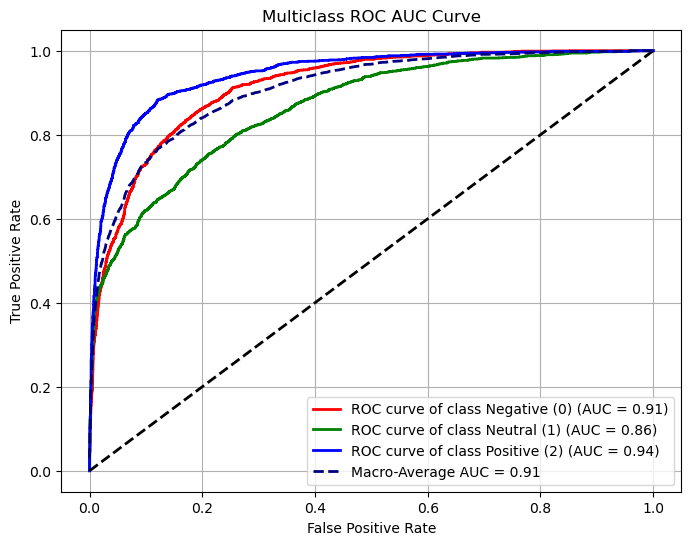

In [48]:
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
from itertools import cycle
import numpy as np

# One-hot encode true labels and predictions
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
y_pred_proba = best_model.predict(X_test_pad)

# Compute ROC curve and ROC area for each class
fpr = dict()
tpr = dict()
roc_auc = dict()
n_classes = 3

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Compute macro-average AUC
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)

for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

# Plot all ROC curves
plt.figure(figsize=(8, 6))
colors = cycle(['red', 'green', 'blue'])
class_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']

for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f"ROC curve of class {class_names[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.plot(all_fpr, mean_tpr, color='navy', linestyle='--', label=f"Macro-Average AUC = {macro_auc:.2f}", lw=2)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC AUC Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


In [ ]:
Model Tuning

In [49]:
import keras_tuner as kt

In [50]:
max_len = X_train_pad.shape[1]

In [51]:
def build_model_tuning1(hp):
    inputs = Input(shape=(max_len,))
    x = Embedding(input_dim=10000, output_dim=hp.Choice('embedding_dim', [128]))(inputs)
    x = Bidirectional(GRU(units=hp.Int('gru1_units', 32, 32)))(x)
    x = Dropout(0.5)(x)
    x = Dense(16, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [52]:
tuner1 = kt.Hyperband(
    build_model_tuning1,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    directory='tuning1',
    project_name='iteration1',
    executions_per_trial=1
)

In [53]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

In [54]:
tuner.search(
    X_train_pad, y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights,
    callbacks=[early_stop],
    batch_size=32
)

Trial 10 Complete [00h 09m 41s]
val_accuracy: 0.7348333299160004

Best val_accuracy So Far: 0.8945875763893127
Total elapsed time: 03h 59m 15s

Search: Running Trial #11

Value             |Best Value So Far |Hyperparameter
256               |128               |embedding_dim
128               |32                |gru1_units
0.4               |0.5               |dropout1
32                |64                |gru2_units
0.3               |0.3               |dropout2
16                |16                |dense_units
0.3               |0.2               |dropout3
2                 |2                 |tuner/epochs
0                 |0                 |tuner/initial_epoch
2                 |2                 |tuner/bracket
0                 |0                 |tuner/round

Epoch 1/2
228/750 ━━━━━━━━━━━━━━━━━━━━ 2:15 260ms/step - accuracy: 0.4020 - loss: 1.0716

KeyboardInterrupt: 

In [60]:
best_model1 = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(1)[0]
print("Best Hyperparameters:", best_hyperparameters.values)

Best Hyperparameters: {'embedding_dim': 128, 'gru1_units': 32, 'dropout1': 0.5, 'gru2_units': 64, 'dropout2': 0.3, 'dense_units': 16, 'dropout3': 0.2, 'tuner/epochs': 2, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}


In [61]:
loss1, acc1 = best_model1.evaluate(X_test_pad, y_test)
print(f"\nIteration 1 - Test Accuracy: {acc1:.4f}, Loss: {loss1:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 42ms/step - accuracy: 0.3695 - loss: 2.6161

Iteration 1 - Test Accuracy: 0.3677, Loss: 2.6265


In [62]:
y_pred_proba1 = best_model1.predict(X_test_pad)
y_pred1 = np.argmax(y_pred_proba1, axis=1)
print(classification_report(y_test, y_pred1))

188/188 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step
              precision    recall  f1-score   support

           0       0.36      0.25      0.29      2000
           1       0.41      0.35      0.38      2000
           2       0.35      0.50      0.41      2000

    accuracy                           0.37      6000
   macro avg       0.37      0.37      0.36      6000
weighted avg       0.37      0.37      0.36      6000



In [63]:
f1_pos1 = f1_score(y_test, y_pred1, labels=[2], average='macro')
f1_neg1 = f1_score(y_test, y_pred1, labels=[0], average='macro')
print(f"F1 Positive: {f1_pos1:.4f}, F1 Negative: {f1_neg1:.4f}")

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
auc_macro1 = roc_auc_score(y_test_bin, y_pred_proba1, average='macro', multi_class='ovr')
print(f"Macro-average AUC (Iteration 1): {auc_macro1:.4f}")

F1 Positive: 0.4096, F1 Negative: 0.2949
Macro-average AUC (Iteration 1): 0.5417


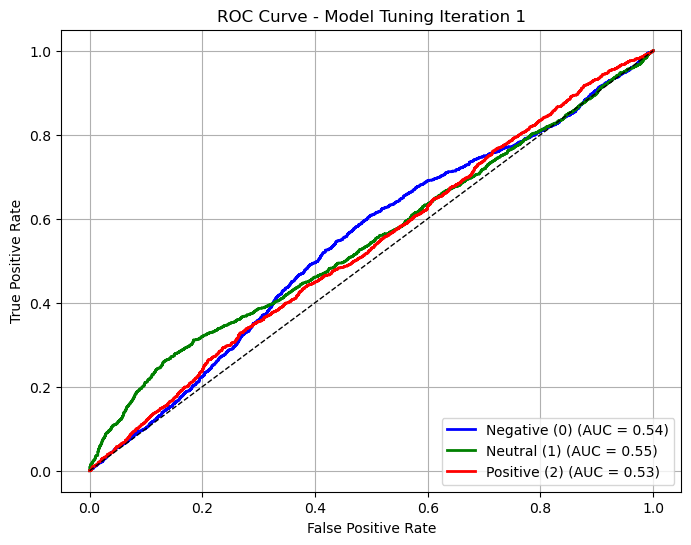

In [64]:
fpr1, tpr1 = dict(), dict()
n_classes = 3

# Compute ROC for each class
for i in range(n_classes):
    fpr1[i], tpr1[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba1[:, i])

# Plot ROC Curve
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red']
class_names = ['Negative (0)', 'Neutral (1)', 'Positive (2)']

for i in range(n_classes):
    auc_score = auc(fpr1[i], tpr1[i])
    plt.plot(fpr1[i], tpr1[i], color=colors[i], lw=2, label=f"{class_names[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("ROC Curve - Model Tuning Iteration 1")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [84]:
def build_model_iteration2():
    inputs = Input(shape=(max_len,))
    x = Embedding(input_dim=10000, output_dim=64)(inputs)  # smaller embedding
    x = Bidirectional(GRU(64, return_sequences=True))(x)
    x = Dropout(0.5)(x)
    x = Bidirectional(GRU(32))(x)
    x = Dropout(0.3)(x)
    x = Dense(32, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(3, activation='softmax')(x)

    model = Model(inputs, outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [85]:
model2 = build_model_iteration2()

In [86]:
model2.fit(
    X_train_pad, y_train,
    epochs=10,
    validation_data=(X_test_pad, y_test),
    class_weight=class_weights,
    callbacks=[early_stop],
    batch_size=32
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 165s 158ms/step - accuracy: 0.4953 - loss: 0.9789 - val_accuracy: 0.7047 - val_loss: 0.7028
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 129s 141ms/step - accuracy: 0.7452 - loss: 0.6125 - val_accuracy: 0.7487 - val_loss: 0.6026
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 139ms/step - accuracy: 0.8085 - loss: 0.4792 - val_accuracy: 0.7580 - val_loss: 0.6010
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 94s 125ms/step - accuracy: 0.8568 - loss: 0.3671 - val_accuracy: 0.7633 - val_loss: 0.6037
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 109ms/step - accuracy: 0.8881 - loss: 0.2991 - val_accuracy: 0.7465 - val_loss: 0.6738
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 107ms/step - accuracy: 0.9165 - loss: 0.2477 - val_accuracy: 0.7477 - val_loss: 0.7240


In [87]:
loss2, acc2 = model2.evaluate(X_test_pad, y_test)
print(f"\nIteration 2 - Test Accuracy: {acc2:.4f}, Loss: {loss2:.4f}")

188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 35ms/step - accuracy: 0.7564 - loss: 0.6189

Iteration 2 - Test Accuracy: 0.7580, Loss: 0.6010


In [88]:
y_pred_proba2 = model2.predict(X_test_pad)
y_pred2 = np.argmax(y_pred_proba2, axis=1)
print(classification_report(y_test, y_pred2))

188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step
              precision    recall  f1-score   support

           0       0.79      0.73      0.76      2000
           1       0.70      0.66      0.68      2000
           2       0.77      0.88      0.82      2000

    accuracy                           0.76      6000
   macro avg       0.76      0.76      0.76      6000
weighted avg       0.76      0.76      0.76      6000



In [89]:
f1_pos2 = f1_score(y_test, y_pred2, labels=[2], average='macro')
f1_neg2 = f1_score(y_test, y_pred2, labels=[0], average='macro')
print(f"F1 Positive: {f1_pos2:.4f}, F1 Negative: {f1_neg2:.4f}")

F1 Positive: 0.8221, F1 Negative: 0.7627


In [90]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
auc_macro2 = roc_auc_score(y_test_bin, y_pred_proba2, average='macro', multi_class='ovr')
print(f"Macro-average AUC (Iteration 2): {auc_macro2:.4f}")

Macro-average AUC (Iteration 2): 0.9089


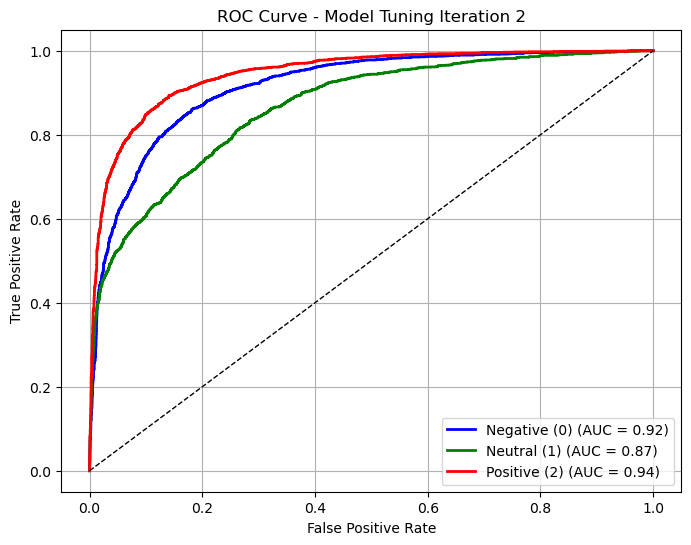

In [91]:
fpr2, tpr2 = dict(), dict()

for i in range(n_classes):
    fpr2[i], tpr2[i], _ = roc_curve(y_test_bin[:, i], y_pred_proba2[:, i])

# Plot ROC Curve
plt.figure(figsize=(8, 6))

for i in range(n_classes):
    auc_score = auc(fpr2[i], tpr2[i])
    plt.plot(fpr2[i], tpr2[i], color=colors[i], lw=2, label=f"{class_names[i]} (AUC = {auc_score:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("ROC Curve - Model Tuning Iteration 2")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [95]:
new_tweets = [
    "I love this product! It's amazing.",
    "I'm not happy with the service.",
    "It's okay, nothing special."
]

# Convert to sequences
new_sequences = tokenizer.texts_to_sequences(new_tweets)

# ✅ Pad with same max_len as used in training
X_new_pad = pad_sequences(new_sequences, maxlen=max_len, padding='post', truncating='post')

# DEBUG: check what's going in
print("New Sequences:", new_sequences)
print("Padded Input:", X_new_pad)

# 🧠 Predict using the first tuned model
pred_probs_1 = best_model1.predict(X_new_pad)
pred_classes_1 = np.argmax(pred_probs_1, axis=1)

# 🧠 Predict using the second tuned model
pred_probs_2 = model2.predict(X_new_pad)
pred_classes_2 = np.argmax(pred_probs_2, axis=1)

# Class label mapping
label_map = {0: "Negative", 1: "Neutral", 2: "Positive"}
pred_labels_1 = [label_map[i] for i in pred_classes_1]
pred_labels_2 = [label_map[i] for i in pred_classes_2]

# ✅ Display results for both models
print("\n--- Predictions from Model Tuning 1 ---")
for tweet, label, probs in zip(new_tweets, pred_labels_1, pred_probs_1):
    print(f"Tweet: {tweet}")
    print(f"Predicted Sentiment: {label} | Probabilities: {probs}\n")

print("--- Predictions from Model Tuning 2 ---")
for tweet, label, probs in zip(new_tweets, pred_labels_2, pred_probs_2):
    print(f"Tweet: {tweet}")
    print(f"Predicted Sentiment: {label} | Probabilities: {probs}\n")

New Sequences: [[17, 289, 15, 4422, 1, 1017], [1, 21, 1213, 20, 2, 1012], [1, 1397, 156, 1871]]
Padded Input: [[  17  289   15 4422    1 1017    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   1   21 1213   20    2 1012    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0]
 [   1 1397  156 1871    0    0    0    0    0    0    0    0   

In [97]:
LLT Prompt: -this is base code give Step-by-step guide to hyperparameter tuning in deep recurrent neural networks.
            -How to improve initial accuracy during tuning?
            -how predicting the sentiment of two different trained deep learning models from your tuning iterations.

SyntaxError: invalid syntax (3375199488.py, line 1)